In [ ]:
# import os
# import cv2
# import numpy as np
# import time
# import random
# from sklearn.model_selection import train_test_split, GridSearchCV
# from sklearn.svm import SVC
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.cluster import KMeans
# from sklearn.preprocessing import StandardScaler
# from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
# import matplotlib.pyplot as plt
# import seaborn as sns

# #  
# # CONFIGURATION
# #  
# # Path to the 'Final_Training/Images' folder containing subfolders 00000 to 00042
# DATASET_PATH =r"C:\Users\lenar\Downloads\GTSRB_Final_Training_Images\GTSRB\Final_Training\Images" #"GTSRB/Final_Training/Images" 
# IMG_SIZE = (64, 64)  # Resize images for consistency (especially for color hist)
# VOCAB_SIZE = 100     # Number of "Visual Words" for SIFT BoW
# SEED = 42            # Random seed for reproducibility
# SAMPLE_FRACTION = 0.2 # Use 0.2 (20%) for debugging, set to 1.0 for full run


# # GTSRB Class ID to Name Mapping
# GTSRB_CLASSES = {
#     0: 'Speed limit (20km/h)', 1: 'Speed limit (30km/h)', 2: 'Speed limit (50km/h)', 
#     3: 'Speed limit (60km/h)', 4: 'Speed limit (70km/h)', 5: 'Speed limit (80km/h)', 
#     6: 'End of speed limit (80km/h)', 7: 'Speed limit (100km/h)', 8: 'Speed limit (120km/h)', 
#     9: 'No passing', 10: 'No passing veh over 3.5 tons', 11: 'Right-of-way at intersection', 
#     12: 'Priority road', 13: 'Yield', 14: 'Stop', 15: 'No vehicles', 
#     16: 'Veh > 3.5 tons prohibited', 17: 'No entry', 18: 'General caution', 
#     19: 'Dangerous curve left', 20: 'Dangerous curve right', 21: 'Double curve', 
#     22: 'Bumpy road', 23: 'Slippery road', 24: 'Road narrows on the right', 
#     25: 'Road work', 26: 'Traffic signals', 27: 'Pedestrians', 28: 'Children crossing', 
#     29: 'Bicycles crossing', 30: 'Beware of ice/snow', 31: 'Wild animals crossing', 
#     32: 'End speed + passing limits', 33: 'Turn right ahead', 34: 'Turn left ahead', 
#     35: 'Ahead only', 36: 'Go straight or right', 37: 'Go straight or left', 
#     38: 'Keep right', 39: 'Keep left', 40: 'Roundabout mandatory', 
#     41: 'End of no passing', 42: 'End no passing veh > 3.5 tons'
# }






In [ ]:

# def load_gtsrb_data(base_path, sample_fraction=1.0):
#     """
#     Loads images and labels from the GTSRB folder structure.
#     sample_fraction: Load only a subset (e.g., 0.1) for faster debugging.
#     """
#     print(f"[INFO] Loading data from {base_path}...")
#     images = []
#     labels = []
    
#     # GTSRB classes are folders 00000 to 00042
#     classes = sorted([d for d in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, d))])
    
#     for class_id, class_name in enumerate(classes):
#         class_dir = os.path.join(base_path, class_name)
#         img_files = os.listdir(class_dir)
        
#         # Optional: verify files are images (ppm or png)
#         img_files = [f for f in img_files if f.endswith('.ppm') or f.endswith('.png')]
        
#         for img_file in img_files:
#             # Random sampling for large datasets if needed
#             if random.random() > sample_fraction:
#                 continue
                
#             img_path = os.path.join(class_dir, img_file)
#             img = cv2.imread(img_path)
            
#             if img is not None:
#                 # Resize immediately to save memory and ensure consistency
#                 img = cv2.resize(img, IMG_SIZE)
#                 images.append(img)
#                 labels.append(class_id)
    
#     print(f"[INFO] Loaded {len(images)} images across {len(classes)} classes.")
#     return np.array(images), np.array(labels)

In [ ]:
# 2. feature extraction methods
# histogram extraction
def extract_color_histograms(images, bins=(8, 8, 8)):
    """
    Method A: 3-Channel Color Histogram (Simple Representation)
    """
    print("[INFO] Extracting Color Histograms...")
    features = []
    for img in images:
        # Convert to HSV (more robust for traffic signs than BGR)
        hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
        
        # Compute histogram
        hist = cv2.calcHist([hsv], [0, 1, 2], None, bins, [0, 180, 0, 256, 0, 256])
        
        # Normalize to account for different image scales (if not resized)
        cv2.normalize(hist, hist)
        features.append(hist.flatten())
        
    return np.array(features)

In [ ]:
# # 2. feature extraction methods
# # visual bag of words
# class VisualBagOfWords:
#     """
#     Method B: SIFT + Bag of Words (Complex Representation)
#     """
#     def __init__(self, k=100):
#         self.k = k
#         self.kmeans = None
#         self.sift = cv2.SIFT_create()
#         self.scaler = StandardScaler()

#     def fit(self, images):
#         """
#         1. Detect SIFT features from all (or a subset of) images.
#         2. Cluster them to create a vocabulary (Codebook).
#         """
#         print("[INFO] BoW: Detecting keypoints for vocabulary generation...")
#         descriptor_list = []
        
#         # Optimization: Use a random subset of images to build vocabulary to save time
#         sample_indices = np.random.choice(len(images), min(len(images), 1000), replace=False)
        
#         for idx in sample_indices:
#             gray = cv2.cvtColor(images[idx], cv2.COLOR_BGR2GRAY)
#             kp, des = self.sift.detectAndCompute(gray, None)
#             if des is not None:
#                 descriptor_list.append(des)
        
#         # Stack all descriptors vertically
#         all_descriptors = np.vstack(descriptor_list)
#         print(f"[INFO] BoW: Clustering {len(all_descriptors)} descriptors into {self.k} words...")
        
#         # K-Means clustering
#         self.kmeans = KMeans(n_clusters=self.k, random_state=SEED, n_init=10)
#         self.kmeans.fit(all_descriptors)
#         print("[INFO] BoW: Vocabulary created.")

#     def transform(self, images):
#         """
#         Convert each image into a histogram of visual word counts.
#         """
#         print("[INFO] BoW: Encoding images...")
#         histograms = []
        
#         for img in images:
#             gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
#             kp, des = self.sift.detectAndCompute(gray, None)
            
#             hist = np.zeros(self.k)
#             if des is not None:
#                 # Predict which visual word each descriptor belongs to
#                 predictions = self.kmeans.predict(des)
#                 for pred in predictions:
#                     hist[pred] += 1
            
#             # Normalize histogram (frequency)
#             if np.sum(hist) > 0:
#                 hist = hist / np.sum(hist)
            
#             histograms.append(hist)
            
#         return np.array(histograms)


In [ ]:
# # 3. classifier eval wrapper

# def evaluate_classifier(name, clf, X_train, X_test, y_train, y_test):
#     print(f"\n  Training {name}  ")
    
#     # 1. Training Time
#     start_train = time.time()
#     clf.fit(X_train, y_train)
#     end_train = time.time()
#     train_time = end_train - start_train
    
#     # 2. Inference Time
#     start_test = time.time()
#     y_pred = clf.predict(X_test)
#     end_test = time.time()
#     test_time = end_test - start_test
    
#     # 3. Metrics
#     acc = accuracy_score(y_test, y_pred)
#     print(f"Accuracy: {acc:.4f}")
#     print(f"Training Time: {train_time:.2f}s")
#     print(f"Inference Time: {test_time:.2f}s")
#     print("\nClassification Report:")
#     print(classification_report(y_test, y_pred, digits=3))
    
#     return y_pred

In [ ]:
# # 4. plotting and visualization functions
# def plot_samples(images, labels, class_names=None, num_samples=5):
#     """
#     Displays a random row of images from the dataset to verify loading.
#     """
#     plt.figure(figsize=(15, 3))
#     indices = np.random.choice(len(images), num_samples, replace=False)
    
#     for i, idx in enumerate(indices):
#         plt.subplot(1, num_samples, i + 1)
#         # Convert BGR (OpenCV) to RGB (Matplotlib)
#         img_rgb = cv2.cvtColor(images[idx], cv2.COLOR_BGR2RGB)
#         plt.imshow(img_rgb)
#         label = labels[idx]
#         title = f"Class: {label}" if class_names is None else class_names[label]
#         plt.title(title)
#         plt.axis('off')
    
#     plt.suptitle("Random Dataset Samples")
#     plt.tight_layout()
#     plt.show()

# def plot_class_distribution(labels):
#     """
#     Plots a histogram of the number of images per class.
#     Essential for showing the imbalance in GTSRB.
#     """
#     plt.figure(figsize=(12, 5))
#     unique, counts = np.unique(labels, return_counts=True)
#     sns.barplot(x=unique, y=counts, palette="viridis")
#     plt.title("Class Distribution (GTSRB Training Set)")
#     plt.xlabel("Class ID")
#     plt.ylabel("Number of Images")
#     plt.show()

# def visualize_sift_keypoints(image):
#     """
#     Visualizes SIFT keypoints on a single image.
#     Good for the 'Qualitative' analysis section of your report.
#     """
#     sift = cv2.SIFT_create()
#     gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
#     kp = sift.detect(gray, None)
    
#     img_sift = cv2.drawKeypoints(image, kp, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
    
#     plt.figure(figsize=(6, 6))
#     plt.imshow(cv2.cvtColor(img_sift, cv2.COLOR_BGR2RGB))
#     plt.title(f"SIFT Features Detected: {len(kp)}")
#     plt.axis('off')
#     plt.show()

# def plot_confusion_matrix_heatmap(y_test, y_pred, model_name):
#     """
#     Plots the Confusion Matrix as a heatmap.
#     Required by the exercise to analyze errors per class.
#     """
#     cm = confusion_matrix(y_test, y_pred)
    
#     plt.figure(figsize=(12, 10))
#     sns.heatmap(cm, annot=False, fmt='d', cmap='Blues', xticklabels=True, yticklabels=True)
#     plt.title(f"Confusion Matrix: {model_name}")
#     plt.xlabel("Predicted Label")
#     plt.ylabel("True Label")
#     plt.show()

In [ ]:
# # 4. plotting and visualization functions
# def plot_rgb_histograms_per_class(images, labels):
#     """
#     Plots the average R, G, B histograms for specific classes
#     to visualize dominant colors.
#     """
#     print("[INFO] analyzing RGB distributions...")
    
#     # Select distinct classes to compare
#     # Class 4: Speed Limit 70 (Red Border)
#     # Class 38: Keep Right (Blue Background)
#     target_classes = [4, 38] 
#     class_names = {4: "Class 4: Speed Limit (Red)", 38: "Class 38: Keep Right (Blue)"}
    
#     plt.figure(figsize=(15, 6))
    
#     for i, cls in enumerate(target_classes):
#         indices = np.where(labels == cls)[0]
#         if len(indices) == 0: continue
            
#         class_imgs = images[indices]
        
#         # Initialize sums for B, G, R channels
#         # OpenCV loads images as BGR, so 0=Blue, 1=Green, 2=Red
#         avg_hist_b = np.zeros((256, 1))
#         avg_hist_g = np.zeros((256, 1))
#         avg_hist_r = np.zeros((256, 1))
        
#         for img in class_imgs:
#             avg_hist_b += cv2.calcHist([img], [0], None, [256], [0, 256])
#             avg_hist_g += cv2.calcHist([img], [1], None, [256], [0, 256])
#             avg_hist_r += cv2.calcHist([img], [2], None, [256], [0, 256])
            
#         # Average and Normalize
#         n = len(class_imgs)
#         avg_hist_b = (avg_hist_b / n).flatten()
#         avg_hist_g = (avg_hist_g / n).flatten()
#         avg_hist_r = (avg_hist_r / n).flatten()
        
#         # Max-normalize for plotting clarity (0 to 1 range)
#         cv2.normalize(avg_hist_b, avg_hist_b)
#         cv2.normalize(avg_hist_g, avg_hist_g)
#         cv2.normalize(avg_hist_r, avg_hist_r)

#         # Plot
#         plt.subplot(1, 2, i+1)
#         plt.title(class_names[cls])
#         plt.plot(avg_hist_r, color='r', label='Red Channel')
#         plt.plot(avg_hist_g, color='g', label='Green Channel')
#         plt.plot(avg_hist_b, color='b', label='Blue Channel')
#         plt.xlabel("Pixel Intensity (0-255)")
#         plt.ylabel("Frequency")
#         plt.legend()
#         plt.grid(alpha=0.3)

#     plt.tight_layout()
#     plt.show()

In [ ]:
# # predict new images from file path -> todo CLI framework
# def predict_from_path(file_path, svm_model, rf_model, bow_model):
#     """
#     Loads an image from a file path (supports .ppm) and prints Top 5 predictions.
#     """
#     print(f"\n" + "="*60)
#     print(f"PREDICTING: {file_path}")
#     print("="*60)

#     # 1. Load Image
#     if not os.path.exists(file_path):
#         print(f"[ERROR] File not found at: {file_path}")
#         return

#     # cv2.imread handles .ppm automatically
#     img = cv2.imread(file_path)
    
#     if img is None:
#         print("[ERROR] Failed to load image. Check format.")
#         return

#     # 2. Resize to match training data (64x64)
#     img_resized = cv2.resize(img, (64, 64))

#     #   MODEL A: SVM (Color Histogram)  
#     try:
#         # Extract histogram
#         # Note: extract_color_histograms expects a LIST of images
#         feat_hist = extract_color_histograms([img_resized]) 
        
#         # Predict Probabilities
#         if hasattr(svm_model, "best_estimator_"):
#             probs_svm = svm_model.best_estimator_.predict_proba(feat_hist)[0]
#         else:
#             probs_svm = svm_model.predict_proba(feat_hist)[0]
            
#         top5_indices = np.argsort(probs_svm)[::-1][:5]
        
#         print(f"\n[Model A] SVM (Color Hist):")
#         for i, idx in enumerate(top5_indices, 1):
#             class_name = GTSRB_CLASSES.get(idx, "Unknown")
#             confidence = probs_svm[idx] * 100
#             print(f"   {i}. {class_name:<30} | Confidence: {confidence:.2f}%")
            
#     except Exception as e:
#         print(f"[Model A Error] {e}")

#     #  MODEL B: Random Forest (SIFT BoW) 
#     try:
#         # Transform using BoW vocabulary
#         feat_bow = bow_model.transform([img_resized])
        
#         # Predict Probabilities
#         probs_rf = rf_model.predict_proba(feat_bow)[0]
#         top5_indices = np.argsort(probs_rf)[::-1][:5]
        
#         print(f"\n[Model B] Random Forest (SIFT BoW):")
#         for i, idx in enumerate(top5_indices, 1):
#             class_name = GTSRB_CLASSES.get(idx, "Unknown")
#             confidence = probs_rf[idx] * 100
#             print(f"   {i}. {class_name:<30} | Confidence: {confidence:.2f}%")

#     except Exception as e:
#         print(f"[Model B Error] Could not detect keypoints (image too blurry/dark?).")

[INFO] Loading data from C:\Users\lenar\Downloads\GTSRB_Final_Training_Images\GTSRB\Final_Training\Images...
[INFO] Loaded 7797 images across 43 classes.


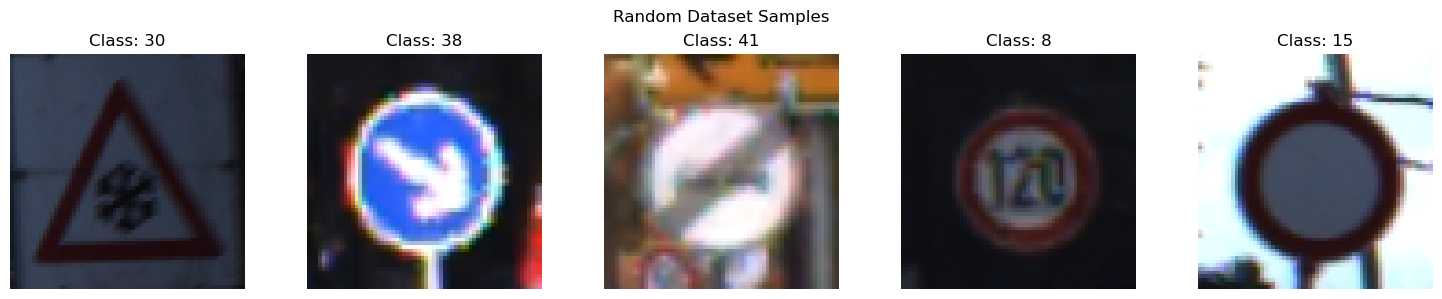

C:\Users\lenar\AppData\Local\Temp\ipykernel_23144\1135343508.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=unique, y=counts, palette="viridis")


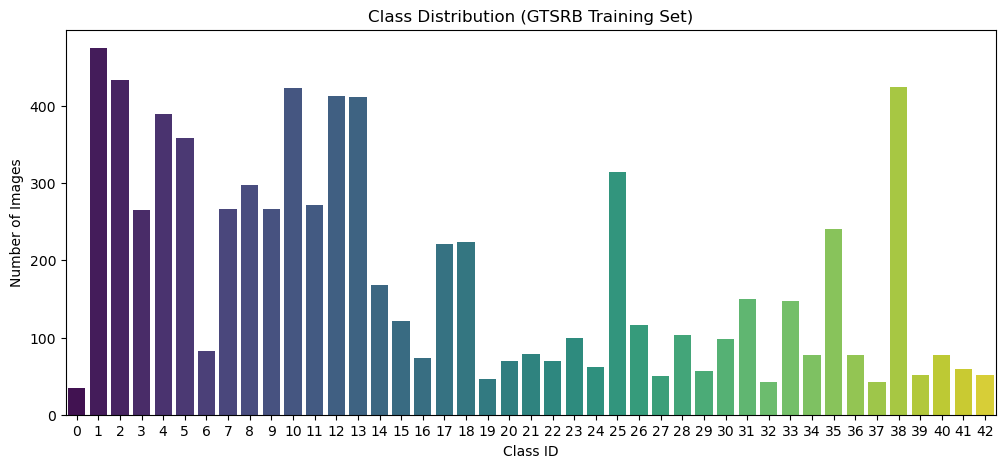

[INFO] analyzing RGB distributions...


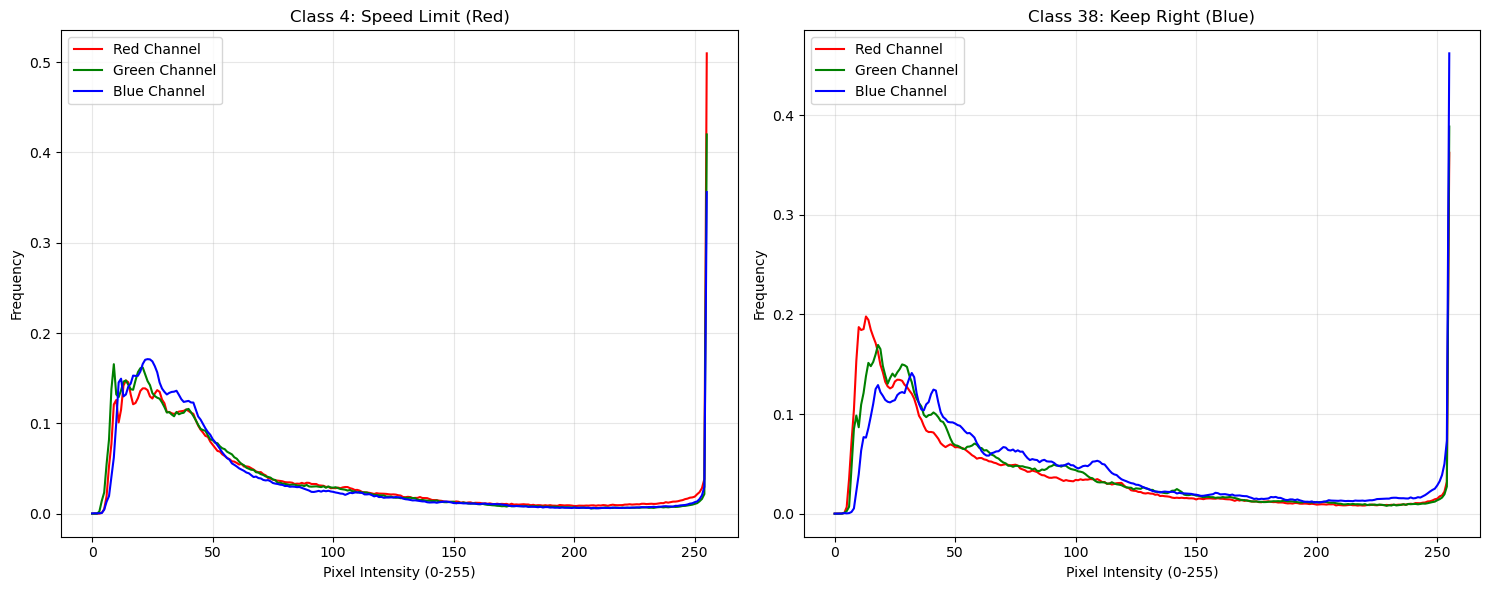

[INFO] Splitting data...

EXPERIMENT 1: COLOR HISTOGRAMS (Simple)
[INFO] Extracting Color Histograms...
[INFO] Extracting Color Histograms...
Optimizing SVM...

--- Training SVM (Color Hist) ---
Accuracy: 0.7660
Training Time: 53.31s
Inference Time: 3.07s

Classification Report:
              precision    recall  f1-score   support

           0      1.000     0.857     0.923         7
           1      0.708     0.842     0.769        95
           2      0.630     0.724     0.674        87
           3      0.706     0.679     0.692        53
           4      0.525     0.679     0.592        78
           5      0.574     0.750     0.651        72
           6      0.867     0.812     0.839        16
           7      0.725     0.698     0.712        53
           8      0.815     0.733     0.772        60
           9      0.700     0.660     0.680        53
          10      0.660     0.776     0.714        85
          11      0.833     0.741     0.784        54
          12     

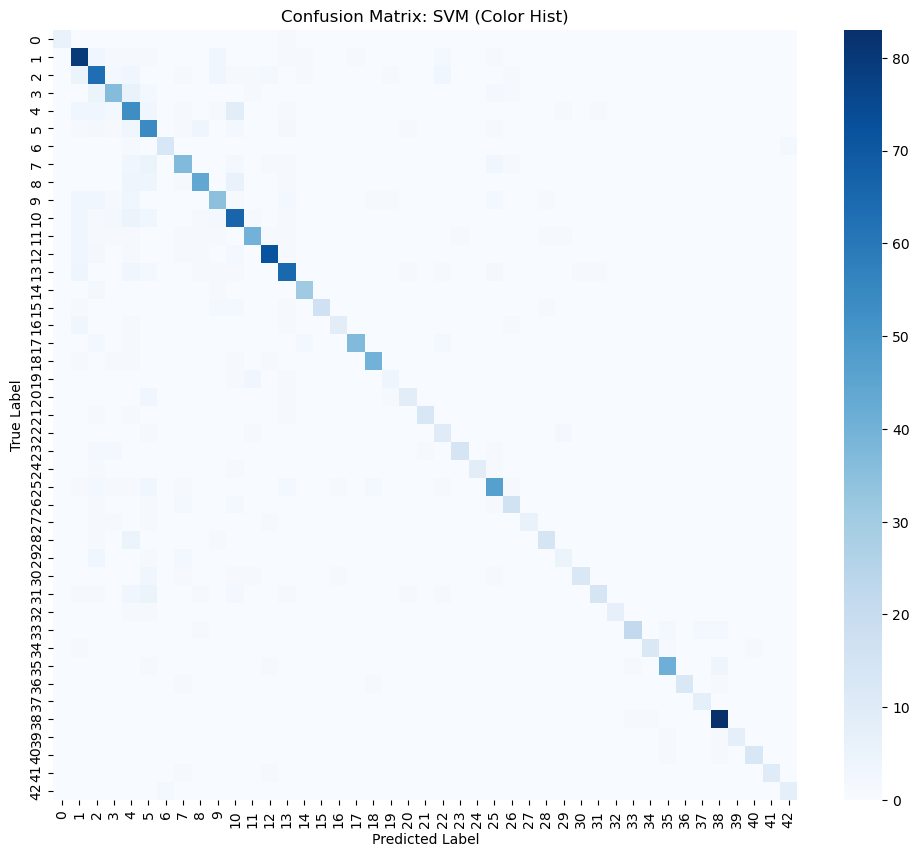


EXPERIMENT 2: SIFT + BoW (Complex)
[INFO] Visualizing SIFT features on a random training sample...


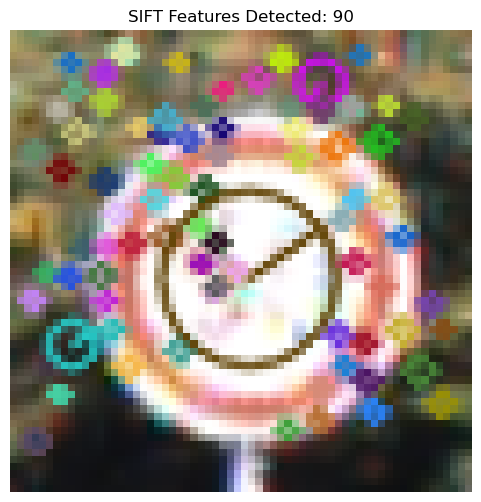

[INFO] BoW: Detecting keypoints for vocabulary generation...
[INFO] BoW: Clustering 25474 descriptors into 100 words...
[INFO] BoW: Vocabulary created.
[INFO] BoW: Encoding images...
[INFO] BoW: Encoding images...

--- Training Random Forest (SIFT BoW) ---
Accuracy: 0.5327
Training Time: 0.25s
Inference Time: 0.03s

Classification Report:
              precision    recall  f1-score   support

           0      1.000     0.143     0.250         7
           1      0.673     0.779     0.722        95
           2      0.744     0.770     0.757        87
           3      0.512     0.415     0.458        53
           4      0.708     0.654     0.680        78
           5      0.580     0.556     0.567        72
           6      0.900     0.562     0.692        16
           7      0.683     0.528     0.596        53
           8      0.300     0.150     0.200        60
           9      0.607     0.642     0.624        53
          10      0.270     0.624     0.377        85
          

c:\Users\lenar\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\lenar\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\lenar\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


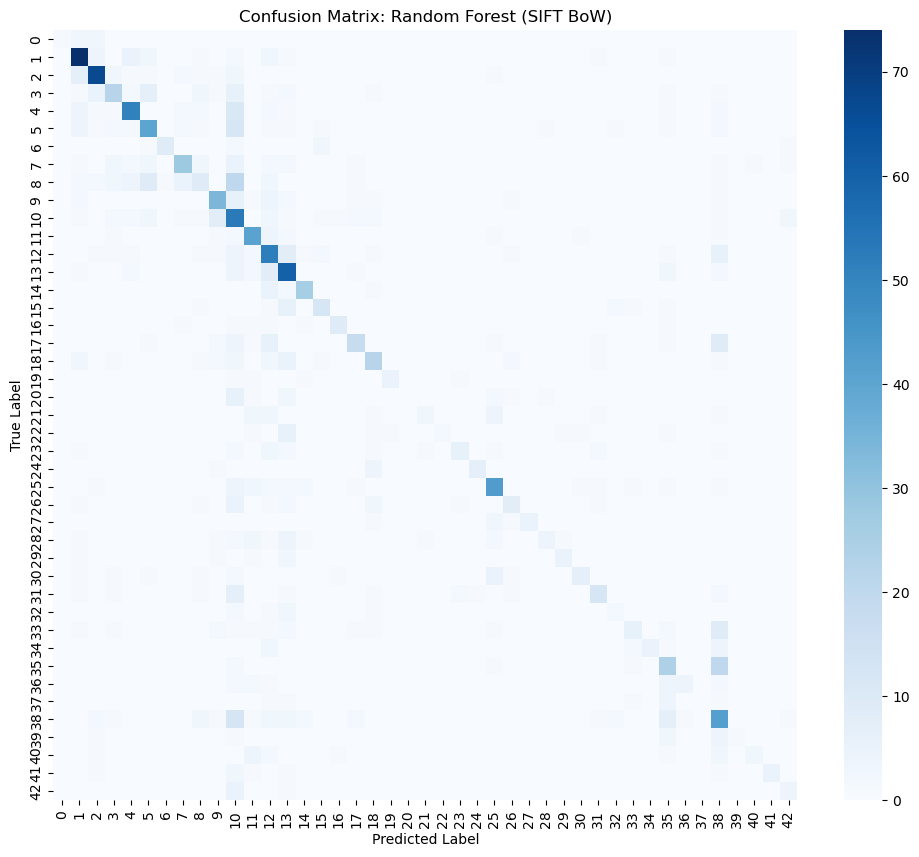


[DONE] Baseline evaluation complete.


In [ ]:
# # A. Load Data for Trafic Sign Recognition
# X, y = load_gtsrb_data(DATASET_PATH, sample_fraction=SAMPLE_FRACTION)

# # B. Visualize Data (Requirement: Understanding representation)
# plot_samples(X, y)
# plot_class_distribution(y)

# plot_rgb_histograms_per_class(X, y)
# # C. Split Data (Stratified due to class imbalance)
# print("[INFO] Splitting data...")
# X_train_img, X_test_img, y_train, y_test = train_test_split(
#     X, y, test_size=0.2, stratify=y, random_state=SEED
# )

# #  EXPERIMENT 1: Color Histogram Features 
# print("\n" + "="*40 + "\nEXPERIMENT 1: COLOR HISTOGRAMS (Simple)\n" + "="*40)

# # 1. Extract
# X_train_hist = extract_color_histograms(X_train_img)
# X_test_hist = extract_color_histograms(X_test_img)

# # 2. Train SVM (GridSearch)
# print("Optimizing SVM...")
# # Using a smaller grid for demonstration; expand for full report
# param_grid = {'C': [1, 10], 'gamma': ['scale']} 
# svm_grid = GridSearchCV(SVC(kernel='rbf', probability=True), param_grid, cv=3, n_jobs=-1)

# y_pred_svm = evaluate_classifier("SVM (Color Hist)", svm_grid, X_train_hist, X_test_hist, y_train, y_test)

# # 3. Analyze Errors
# plot_confusion_matrix_heatmap(y_test, y_pred_svm, "SVM (Color Hist)")

# #  EXPERIMENT 2: SIFT + Bag of Words  
# print("\n" + "="*40 + "\nEXPERIMENT 2: SIFT + BoW (Complex)\n" + "="*40)

# # 1. Inspect Feature Extractor
# print("[INFO] Visualizing SIFT features on a random training sample...")
# visualize_sift_keypoints(X_train_img[np.random.randint(len(X_train_img))])

# # 2. Build Vocabulary (Fit on Train only) & Extract
# bow_model = VisualBagOfWords(k=VOCAB_SIZE)
# bow_model.fit(X_train_img) 

# X_train_bow = bow_model.transform(X_train_img)
# X_test_bow = bow_model.transform(X_test_img)

# # 3. Train Random Forest
# rf_clf = RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1)

# y_pred_rf = evaluate_classifier("Random Forest (SIFT BoW)", rf_clf, X_train_bow, X_test_bow, y_train, y_test)

# # 4. Analyze Errors
# plot_confusion_matrix_heatmap(y_test, y_pred_rf, "Random Forest (SIFT BoW)")

# print("\n[DONE] Baseline evaluation complete.")

In [ ]:
# test_path = r"C:\Users\lenar\Downloads\GTSRB_Final_Training_Images\GTSRB\Final_Training\Images\00042\00002_00015.ppm"
# test_path2 = r"C:\Users\lenar\Downloads\Screenshot 2026-01-11 172800.png"
# predict_from_path(test_path, svm_grid, rf_clf, bow_model)



NameError: name 'predict_from_path' is not defined

In [8]:
import sys
import os
import cv2
import numpy as np
import time
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import random

current_dir = os.getcwd()
parent_dir = os.path.dirname(current_dir) # ->Exercise3

sys.path.append(parent_dir)
from data.load_cifar import retrieve_all_cifar, unpickle

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

#  
# 1. CONFIGURATION & CLASS DEFINITIONS
#  
IMG_SIZE = (64, 64)       # Standardize size (SIFT needs larger images than 32x32)
VOCAB_SIZE = 100          # Visual Words for BoW
SEED = 42                 # Reproducibility

# GTSRB Classes
GTSRB_CLASSES = {
    0: 'Speed 20', 1: 'Speed 30', 2: 'Speed 50', 3: 'Speed 60', 4: 'Speed 70', 
    5: 'Speed 80', 6: 'End Speed 80', 7: 'Speed 100', 8: 'Speed 120', 9: 'No passing', 
    10: 'No passing >3.5t', 11: 'Right-of-way', 12: 'Priority road', 13: 'Yield', 
    14: 'Stop', 15: 'No vehicles', 16: 'Veh >3.5t prohib', 17: 'No entry', 
    18: 'General caution', 19: 'Curve left', 20: 'Curve right', 21: 'Double curve', 
    22: 'Bumpy road', 23: 'Slippery', 24: 'Narrows right', 25: 'Road work', 
    26: 'Traffic signals', 27: 'Pedestrians', 28: 'Children', 29: 'Bicycles', 
    30: 'Ice/Snow', 31: 'Wild animals', 32: 'End limits', 33: 'Turn right', 
    34: 'Turn left', 35: 'Ahead only', 36: 'Straight/Right', 37: 'Straight/Left', 
    38: 'Keep right', 39: 'Keep left', 40: 'Roundabout', 41: 'End no passing', 
    42: 'End no pass >3.5t'
}

# CIFAR Classes
CIFAR_CLASSES = {
    0: 'airplane', 1: 'automobile', 2: 'bird', 3: 'cat', 4: 'deer',
    5: 'dog', 6: 'frog', 7: 'horse', 8: 'ship', 9: 'truck'
}

#  
# 2. DATA LOADERS
#  
def load_gtsrb_data(base_path, sample_fraction=1.0):
    print(f"[INFO] Loading GTSRB from {base_path}...")
    images, labels = [], []
    if not os.path.exists(base_path): return np.array([]), np.array([])

    classes = sorted([d for d in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, d))])
    for class_id, class_name in enumerate(classes):
        class_dir = os.path.join(base_path, class_name)
        img_files = [f for f in os.listdir(class_dir) if f.endswith(('.ppm', '.png'))]
        for img_file in img_files:
            if random.random() > sample_fraction: continue
            img = cv2.imread(os.path.join(class_dir, img_file))
            if img is not None:
                images.append(cv2.resize(img, IMG_SIZE))
                labels.append(class_id)
    return np.array(images), np.array(labels)

def load_cifar_adapter(sample_fraction=1.0):
    print(f"[INFO] Loading CIFAR-10 via custom loader...")
    # Calls your imported function
    raw_data = retrieve_all_cifar("train") 
    
    X_flat = np.array(raw_data['data'])
    y = np.array(raw_data['labels'])
    
    # Sampling
    if sample_fraction < 1.0:
        indices = np.random.choice(len(y), int(len(y)*sample_fraction), replace=False)
        X_flat = X_flat[indices]
        y = y[indices]

    # Reshape (N, 3072) -> (N, 3, 32, 32) -> (N, 32, 32, 3)
    X_images = X_flat.reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)
    
    # Convert RGB(CIFAR) -> BGR(OpenCV) and Resize
    X_processed = []
    for img in X_images:
        img_bgr = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
        X_processed.append(cv2.resize(img_bgr, IMG_SIZE))
        
    return np.array(X_processed), y

#  
# 3. VISUALIZATION
#  
def visualize_sift_keypoints(image):
    """Plots the specific SIFT image you asked for."""
    sift = cv2.SIFT_create()
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    kp = sift.detect(gray, None)
    img_sift = cv2.drawKeypoints(image, kp, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
    
    plt.figure(figsize=(6, 6))
    plt.imshow(cv2.cvtColor(img_sift, cv2.COLOR_BGR2RGB))
    plt.title(f"SIFT Features Detected: {len(kp)}")
    plt.axis('off')
    plt.show()

#  
# 4. FEATURE EXTRACTION
#  
def extract_color_histograms(images, bins=(8, 8, 8)):
    features = []
    for img in images:
        hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
        hist = cv2.calcHist([hsv], [0, 1, 2], None, bins, [0, 180, 0, 256, 0, 256])
        cv2.normalize(hist, hist)
        features.append(hist.flatten())
    return np.array(features)

class VisualBagOfWords:
    def __init__(self, k=100):
        self.k = k
        self.kmeans = None
        self.sift = cv2.SIFT_create()

    def fit(self, images):
        print("[INFO] BoW: Building vocabulary...")
        descriptor_list = []
        sample_indices = np.random.choice(len(images), min(len(images), 1000), replace=False)
        for idx in sample_indices:
            gray = cv2.cvtColor(images[idx], cv2.COLOR_BGR2GRAY)
            kp, des = self.sift.detectAndCompute(gray, None)
            if des is not None: descriptor_list.append(des)
        
        if descriptor_list:
            all_descriptors = np.vstack(descriptor_list)
            self.kmeans = KMeans(n_clusters=self.k, random_state=SEED, n_init=10).fit(all_descriptors)
            print("[INFO] BoW: Vocabulary created.")
        else:
            print("[WARN] No descriptors found.")

    def transform(self, images):
        histograms = []
        for img in images:
            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            kp, des = self.sift.detectAndCompute(gray, None)
            hist = np.zeros(self.k)
            if des is not None and self.kmeans:
                preds = self.kmeans.predict(des)
                for p in preds: hist[p] += 1
            if np.sum(hist) > 0: hist /= np.sum(hist)
            histograms.append(hist)
        return np.array(histograms)

#  
# 5. PREDICTION HELPER (The "Path" Function)
#  
def predict_from_path(image_path, models_dict, bow_model, class_names):
    """
    Reads image from path, runs all 4 models, prints Top 5 stats.
    models_dict expects: {'Hist_SVM': m, 'Hist_RF': m, 'SIFT_SVM': m, 'SIFT_RF': m}
    """
    print(f"\n{'='*60}\nPREDICTION REPORT: {image_path}\n{'='*60}")
    
    if not os.path.exists(image_path):
        print(f"[ERROR] File not found: {image_path}")
        return

    # Load & Resize
    img = cv2.imread(image_path)
    if img is None:
        print("[ERROR] Failed to load image.")
        return
        
    # Show Image
    plt.figure(figsize=(3,3))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title("Query Image")
    plt.axis('off')
    plt.show()

    img_resized = cv2.resize(img, IMG_SIZE)

    # 1. Prepare Features
    # Feature A: Color Hist
    feat_hist = extract_color_histograms([img_resized])
    
    # Feature B: SIFT BoW
    feat_bow = bow_model.transform([img_resized])

    # 2. Run All Models
    results = {}
    
    # Check which models exist in the dict
    if 'Hist_SVM' in models_dict: results['Hist + SVM'] = (models_dict['Hist_SVM'], feat_hist)
    if 'Hist_RF'  in models_dict: results['Hist + RF']  = (models_dict['Hist_RF'],  feat_hist)
    if 'SIFT_SVM' in models_dict: results['SIFT + SVM'] = (models_dict['SIFT_SVM'], feat_bow)
    if 'SIFT_RF'  in models_dict: results['SIFT + RF']  = (models_dict['SIFT_RF'],  feat_bow)

    # 3. Print Top 5 for each
    for model_name, (model, feature) in results.items():
        print(f"\n--- {model_name} Results ---")
        try:
            # Handle GridSearchCV objects vs direct models
            estimator = model.best_estimator_ if hasattr(model, "best_estimator_") else model
            
            # Get Probabilities
            probs = estimator.predict_proba(feature)[0]
            top5_indices = np.argsort(probs)[::-1][:5]
            
            for rank, idx in enumerate(top5_indices, 1):
                class_label = class_names.get(idx, f"Class {idx}")
                conf = probs[idx] * 100
                print(f"   {rank}. {class_label:<25} : {conf:.2f}%")
        except Exception as e:
            print(f"   [Error] Could not predict: {e}")



In [ ]:
# Plotting related methods
def plot_samples(images, labels, class_names, num_samples=5):
    plt.figure(figsize=(15, 3))
    indices = np.random.choice(len(images), min(len(images), num_samples), replace=False)
    for i, idx in enumerate(indices):
        plt.subplot(1, num_samples, i + 1)
        img_rgb = cv2.cvtColor(images[idx], cv2.COLOR_BGR2RGB)
        plt.imshow(img_rgb)
        label_text = class_names.get(labels[idx], f"Class {labels[idx]}")
        plt.title(label_text, fontsize=9)
        plt.axis('off')
    plt.suptitle("Random Dataset Samples")
    plt.show()

def plot_class_distribution(labels, class_names):
    plt.figure(figsize=(12, 5))
    unique, counts = np.unique(labels, return_counts=True)
    names = [class_names.get(i, str(i)) for i in unique]
    sns.barplot(x=names, y=counts, palette="viridis")
    plt.title("Class Distribution")
    plt.xticks(rotation=90 if len(unique) > 10 else 45)
    plt.tight_layout()
    plt.show()

def plot_rgb_histograms_dynamic(images, labels, class_names):
    unique_classes = np.unique(labels)
    if len(unique_classes) < 2: return
    target_classes = np.random.choice(unique_classes, 2, replace=False)
    
    plt.figure(figsize=(12, 5))
    colors = ['b', 'g', 'r'] # OpenCV is BGR
    
    for i, cls in enumerate(target_classes):
        indices = np.where(labels == cls)[0]
        class_imgs = images[indices]
        plt.subplot(1, 2, i+1)
        name = class_names.get(cls, f"Class {cls}")
        plt.title(f"Avg RGB: {name}")
        
        for ch_idx, col in enumerate(colors):
            avg_hist = np.mean([cv2.calcHist([img], [ch_idx], None, [256], [0, 256]) 
                                for img in class_imgs], axis=0)
            plt.plot(avg_hist, color=col, label=f"Ch {ch_idx}")
        plt.legend()
        plt.grid(alpha=0.3)
    plt.suptitle("RGB Analysis (Random 2 Classes)")
    plt.show()

def visualize_sift_keypoints(image):
    sift = cv2.SIFT_create()
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    kp = sift.detect(gray, None)
    img_sift = cv2.drawKeypoints(image, kp, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
    plt.figure(figsize=(6, 6))
    plt.imshow(cv2.cvtColor(img_sift, cv2.COLOR_BGR2RGB))
    plt.title(f"SIFT Features Detected: {len(kp)}")
    plt.axis('off')
    plt.show()

def plot_confusion_matrix_dynamic(y_test, y_pred, model_name, class_names):
    cm = confusion_matrix(y_test, y_pred)
    unique_labels = sorted(list(set(y_test) | set(y_pred)))
    tick_labels = [class_names.get(i, str(i)) for i in unique_labels]
    
    plt.figure(figsize=(10, 8) if len(unique_labels) < 15 else (14, 14))
    sns.heatmap(cm, annot=False, fmt='d', cmap='Blues', 
                xticklabels=tick_labels, yticklabels=tick_labels)
    plt.title(f"Confusion Matrix: {model_name}")
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

[INFO] Loading GTSRB from C:\Users\lenar\Downloads\GTSRB_Final_Training_Images\GTSRB\Final_Training\Images...

[INFO] 1. Plotting Data Samples...


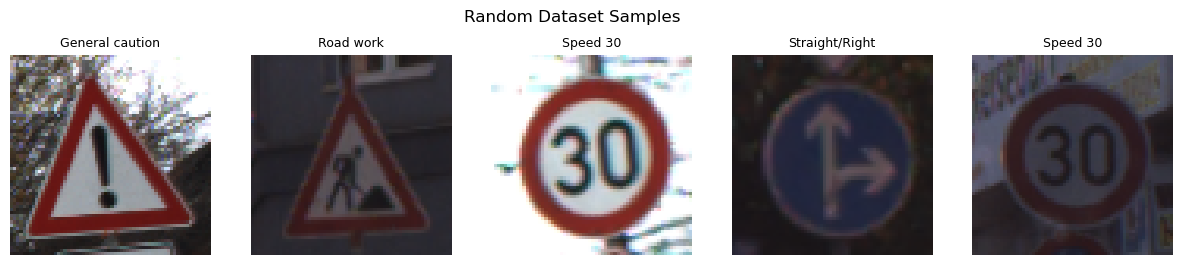


[INFO] 2. Plotting Class Distribution...


C:\Users\lenar\AppData\Local\Temp\ipykernel_20460\1466371566.py:151: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=names, y=counts, palette="viridis")


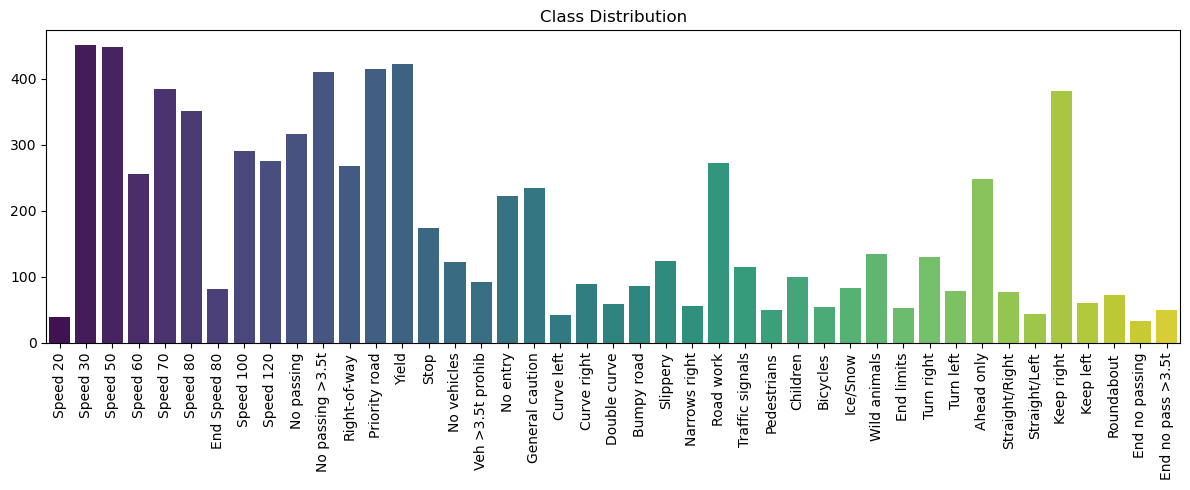


[INFO] 3. Plotting RGB Histograms (Feature Separability)...


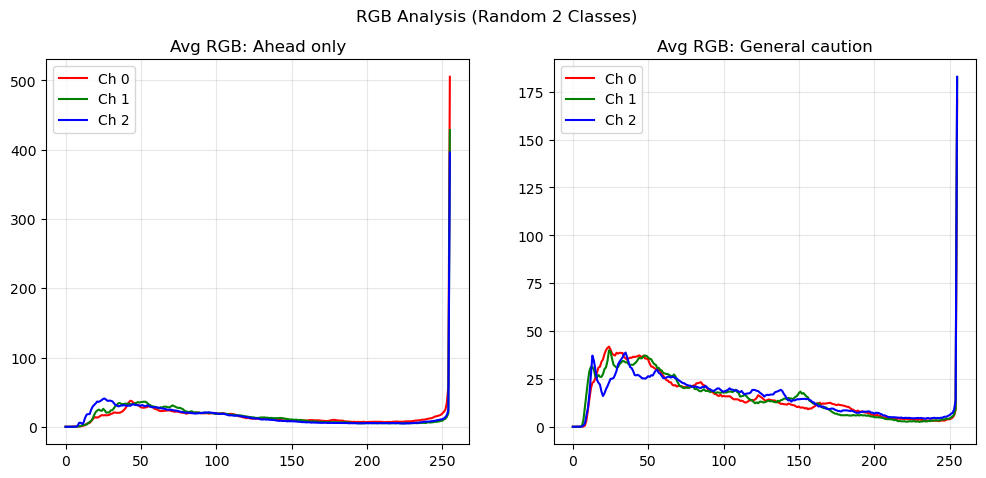


[INFO] 4. Visualizing SIFT Keypoints...


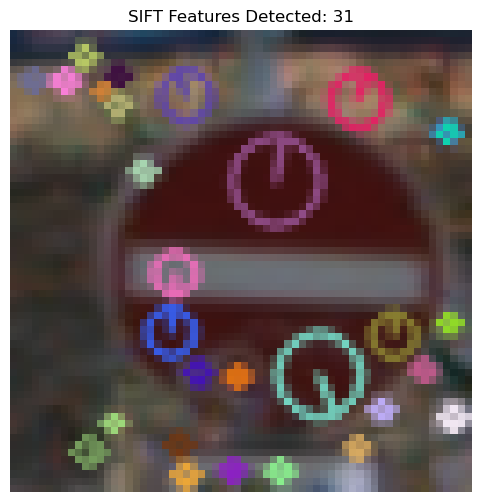


[INFO] Extracting features (Hist + SIFT)...
[INFO] BoW: Building vocabulary...
[INFO] BoW: Vocabulary created.

[TRAINING 1] Hist + SVM...
   Accuracy: 0.7740


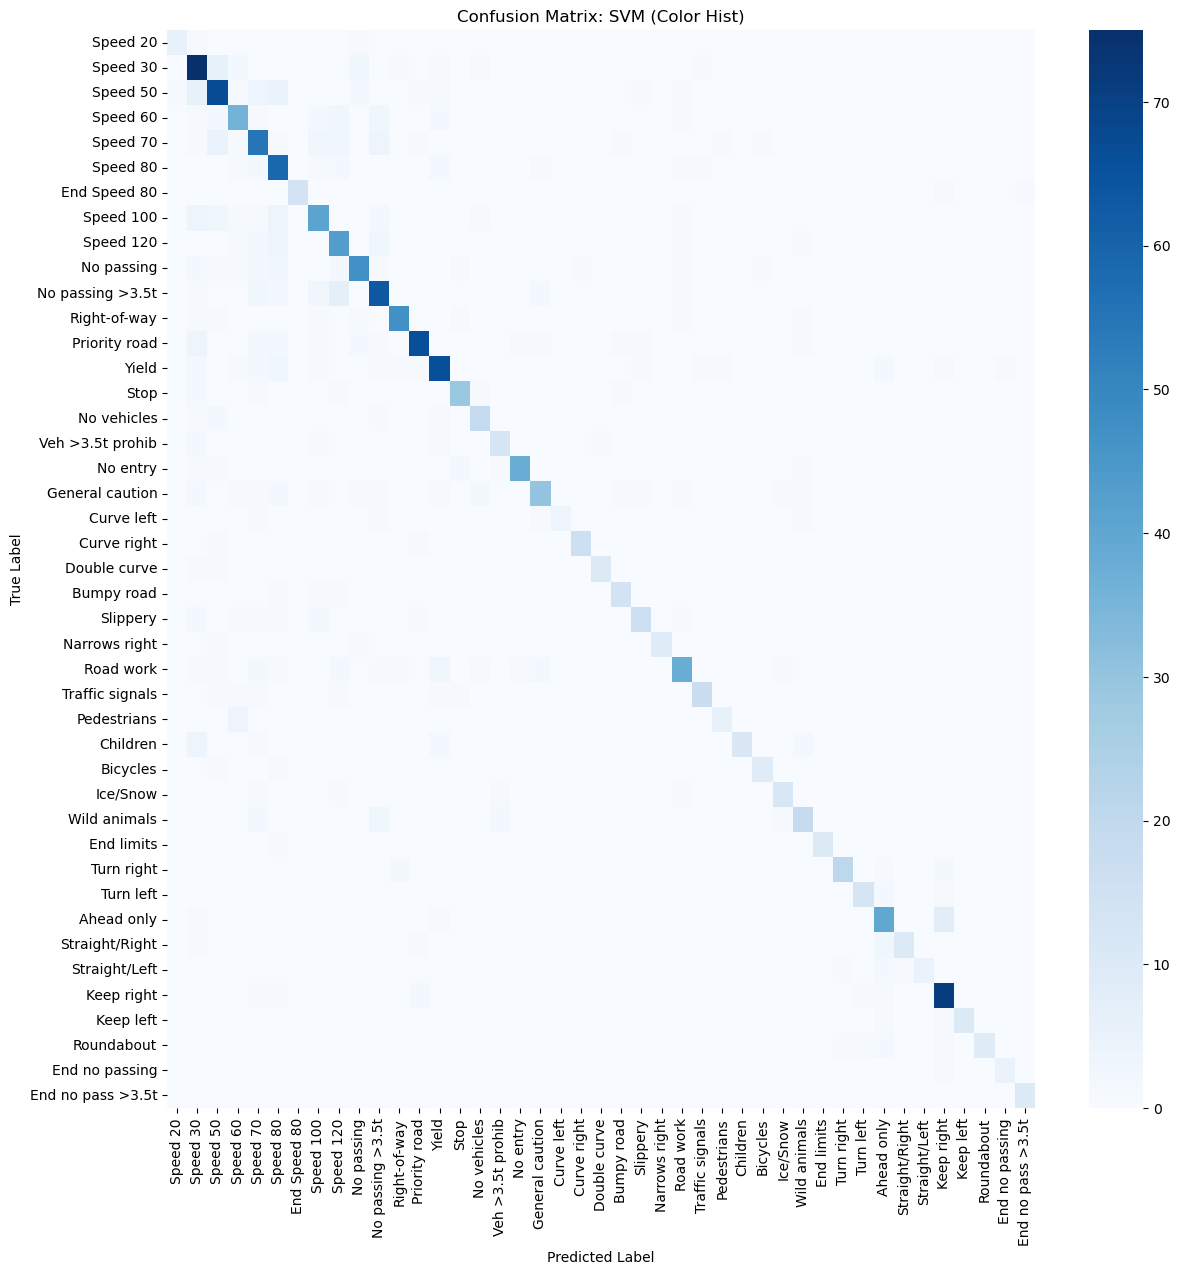


[TRAINING 2] Hist + RF...
   Accuracy: 0.6591

[TRAINING 3] SIFT + SVM...
   Accuracy: 0.5888

[TRAINING 4] SIFT + RF...
   Accuracy: 0.5513


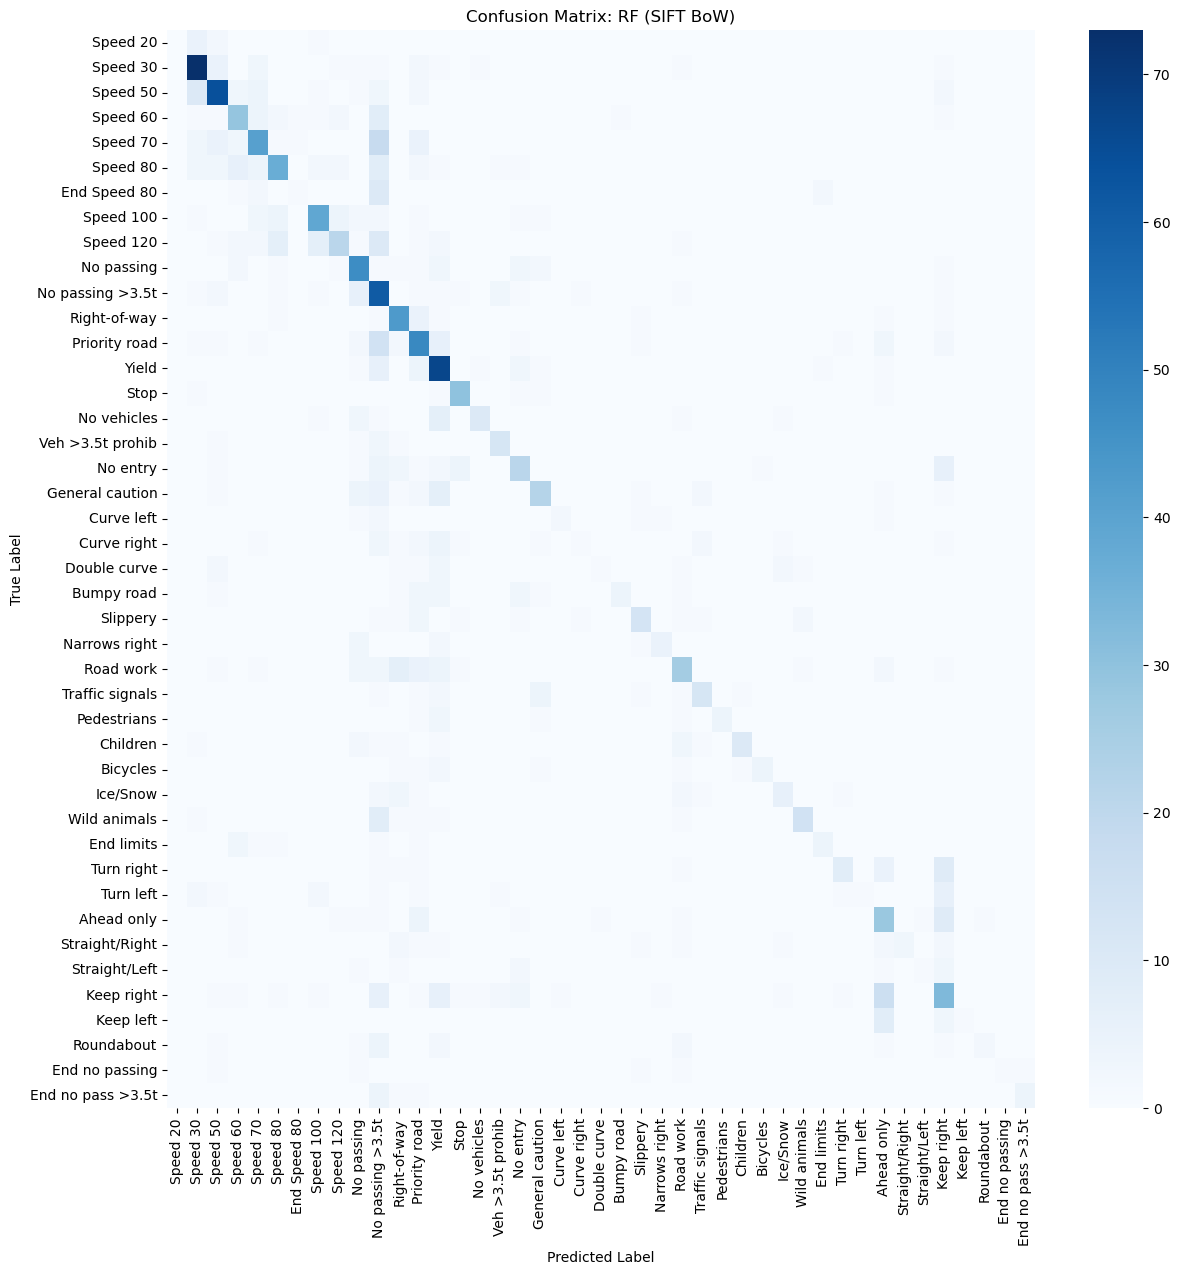


PREDICTION REPORT: temp_test_query.png


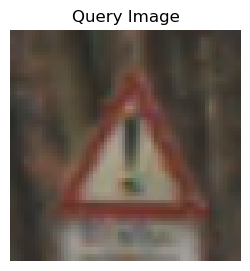


--- Hist + SVM Results ---
   1. General caution           : 86.11%
   2. Wild animals              : 1.97%
   3. No passing                : 1.14%
   4. Speed 20                  : 1.03%
   5. Speed 80                  : 0.83%

--- Hist + RF Results ---
   1. General caution           : 46.00%
   2. No passing                : 14.00%
   3. No entry                  : 8.00%
   4. No passing >3.5t          : 6.00%
   5. Speed 30                  : 6.00%

--- SIFT + SVM Results ---
   1. Slippery                  : 47.61%
   2. Curve right               : 14.77%
   3. Wild animals              : 7.47%
   4. Road work                 : 5.80%
   5. General caution           : 4.96%

--- SIFT + RF Results ---
   1. Traffic signals           : 16.00%
   2. Slippery                  : 14.00%
   3. Double curve              : 10.00%
   4. Bicycles                  : 10.00%
   5. Narrows right             : 8.00%


In [14]:

# FINAL!!!!
# # A. SELECT DATASET ("GTSRB" or "CIFAR")
DATASET_CHOICE = "GTSRB" 

if DATASET_CHOICE == "GTSRB":
    # Adjust path to where your GTSRB images are relative to this notebook
    path = r"C:\Users\lenar\Downloads\GTSRB_Final_Training_Images\GTSRB\Final_Training\Images" 
    X, y = load_gtsrb_data(path, sample_fraction=0.2)
    classes = GTSRB_CLASSES
else:
    # Uses the adapter we built above
    X, y = load_cifar_adapter(sample_fraction=0.1) # Small fraction for speed
    classes = CIFAR_CLASSES

if len(X) == 0:
    print("No data loaded. Stopping.")
    exit()

# B. RUN ALL PLOTS (Data Exploration)
print("\n[INFO] 1. Plotting Data Samples...")
plot_samples(X, y, classes)

print("\n[INFO] 2. Plotting Class Distribution...")
plot_class_distribution(y, classes)

print("\n[INFO] 3. Plotting RGB Histograms (Feature Separability)...")
plot_rgb_histograms_dynamic(X, y, classes)

print("\n[INFO] 4. Visualizing SIFT Keypoints...")
random_idx = np.random.randint(len(X))
visualize_sift_keypoints(X[random_idx])

# C. SPLIT DATA
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=SEED)

# D. PREPARE FEATURES
print("\n[INFO] Extracting features (Hist + SIFT)...")
X_train_hist = extract_color_histograms(X_train)
X_test_hist = extract_color_histograms(X_test)

bow = VisualBagOfWords(k=VOCAB_SIZE)
bow.fit(X_train)
X_train_bow = bow.transform(X_train)
X_test_bow = bow.transform(X_test)

# E. TRAIN 4 MODELS
models_store = {}

# --- 1. Hist + SVM ---
print("\n[TRAINING 1] Hist + SVM...")
svm_hist = GridSearchCV(SVC(kernel='rbf', probability=True), {'C': [1, 10]}, cv=2)
svm_hist.fit(X_train_hist, y_train)
models_store['Hist_SVM'] = svm_hist

# Plot Confusion Matrix for SVM
y_pred_svm = svm_hist.predict(X_test_hist)
print(f"   Accuracy: {accuracy_score(y_test, y_pred_svm):.4f}")
plot_confusion_matrix_dynamic(y_test, y_pred_svm, "SVM (Color Hist)", classes)

# --- 2. Hist + RF ---
print("\n[TRAINING 2] Hist + RF...")
rf_hist = RandomForestClassifier(n_estimators=50, random_state=SEED)
rf_hist.fit(X_train_hist, y_train)
models_store['Hist_RF'] = rf_hist
print(f"   Accuracy: {rf_hist.score(X_test_hist, y_test):.4f}")

# --- 3. SIFT + SVM ---
print("\n[TRAINING 3] SIFT + SVM...")
svm_sift = GridSearchCV(SVC(kernel='rbf', probability=True), {'C': [1, 10]}, cv=2)
svm_sift.fit(X_train_bow, y_train)
models_store['SIFT_SVM'] = svm_sift
print(f"   Accuracy: {svm_sift.score(X_test_bow, y_test):.4f}")

# --- 4. SIFT + RF ---
print("\n[TRAINING 4] SIFT + RF...")
rf_sift = RandomForestClassifier(n_estimators=50, random_state=SEED)
rf_sift.fit(X_train_bow, y_train)
models_store['SIFT_RF'] = rf_sift

# Plot Confusion Matrix for SIFT RF
y_pred_rf = rf_sift.predict(X_test_bow)
print(f"   Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
plot_confusion_matrix_dynamic(y_test, y_pred_rf, "RF (SIFT BoW)", classes)

# F. INFERENCE DEMO
test_img_path = "temp_test_query.png"
cv2.imwrite(test_img_path, X_test[0]) 
predict_from_path(test_img_path, models_store, bow, classes)

   Accuracy: 0.5158


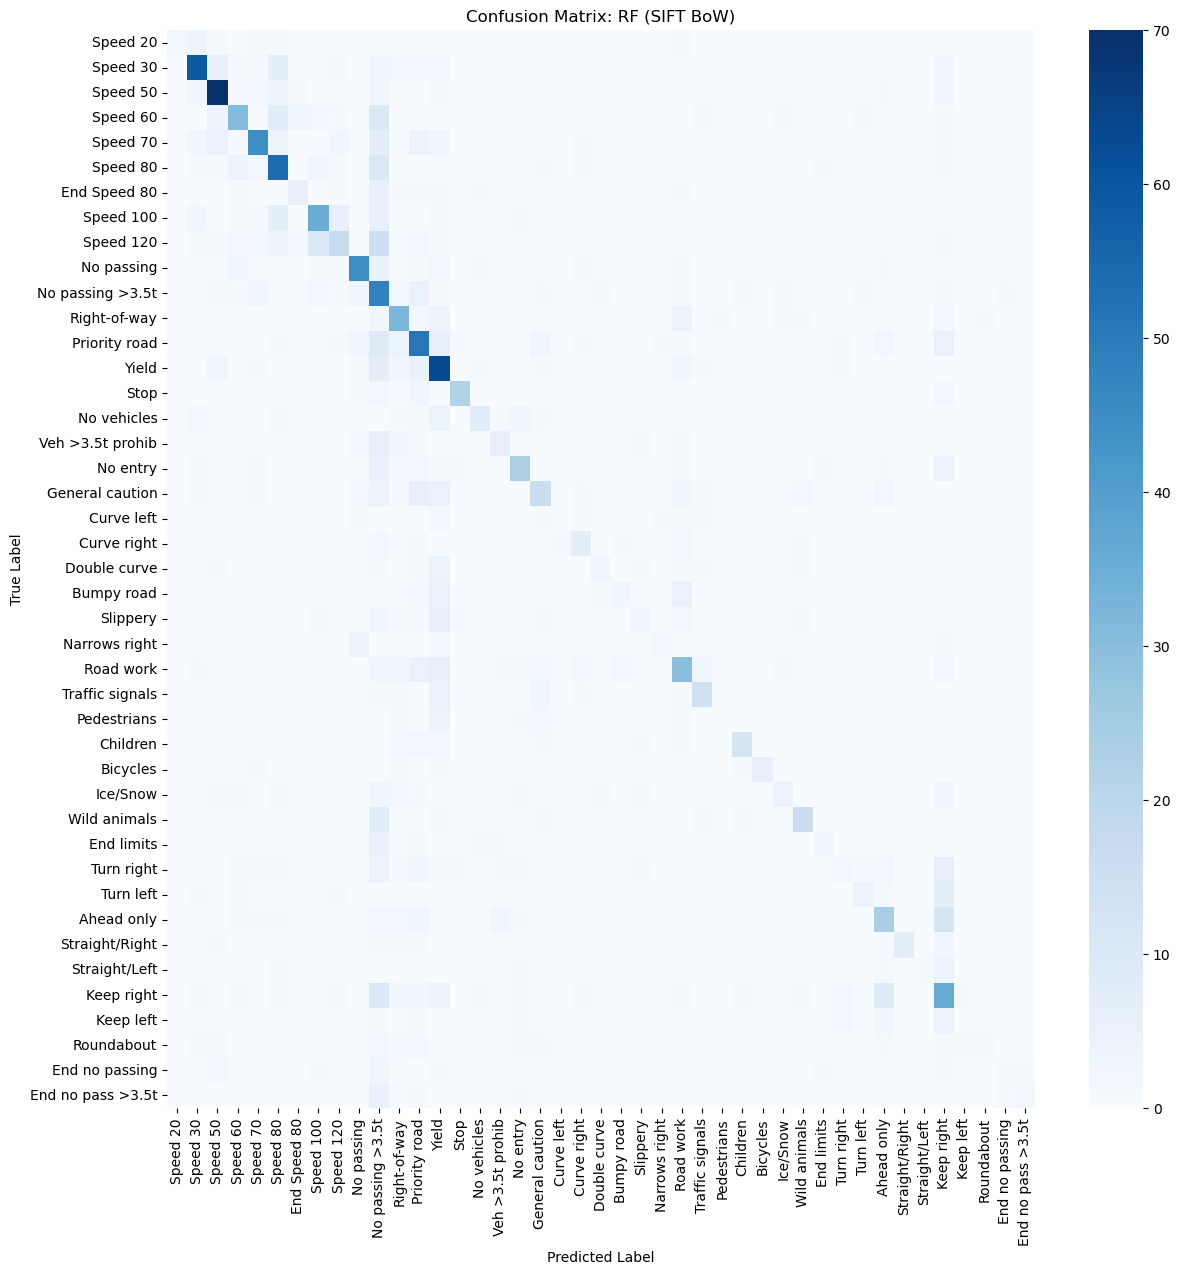

In [11]:
# Plot Confusion Matrix for SIFT RF
y_pred_rf = rf_sift.predict(X_test_bow)
print(f"   Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
plot_confusion_matrix_dynamic(y_test, y_pred_rf, "RF (SIFT BoW)", classes)


PREDICTION REPORT: C:\Users\lenar\Downloads\GTSRB_Final_Training_Images\GTSRB\Final_Training\Images\00018\00038_00029.ppm


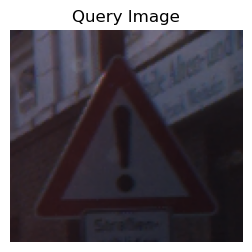


--- Hist + SVM Results ---
   1. Speed 30                  : 63.79%
   2. Veh >3.5t prohib          : 10.27%
   3. Road work                 : 4.87%
   4. No passing >3.5t          : 4.11%
   5. Speed 120                 : 2.25%

--- Hist + RF Results ---
   1. Speed 80                  : 18.00%
   2. Speed 30                  : 18.00%
   3. No passing >3.5t          : 8.00%
   4. Speed 120                 : 8.00%
   5. Yield                     : 6.00%

--- SIFT + SVM Results ---
   1. No passing                : 29.26%
   2. General caution           : 19.74%
   3. Yield                     : 6.96%
   4. Ice/Snow                  : 6.09%
   5. Road work                 : 5.21%

--- SIFT + RF Results ---
   1. No passing                : 64.00%
   2. General caution           : 10.00%
   3. Speed 100                 : 6.00%
   4. Priority road             : 4.00%
   5. Narrows right             : 2.00%


In [15]:
trial_path = r"C:\Users\lenar\Downloads\GTSRB_Final_Training_Images\GTSRB\Final_Training\Images\00018\00038_00029.ppm"
predict_from_path(trial_path, models_store, bow, classes)